Neden LightGBM?
Tabular Verilerde Başarı: LightGBM, özellikle çok sayıda feature içeren tabular verilerde (burada 292 önemli değişken) hızlı ve yüksek performanslı sonuçlar verir.
Hızlı Eğitim & Bellek Verimliliği: Büyük veri setleri (321.717 örnek) için eğitim süresi kısa ve bellek kullanımı optimize edilir.
Hiperparametre Esnekliği ve Early Stopping: Modelin performansını artırmak için kolayca ayarlanabilen parametreler ve early stopping gibi mekanizmalarla aşırı öğrenmenin önüne geçilebilir.



In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb # LightGBM için import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import random # generate_random_composition için

#-------------------------------------------------------------------------------
# Blok 1: Model Eğitimi, Değerlendirmesi ve Kaydedilmesi (LightGBM ile)
#-------------------------------------------------------------------------------
def train_evaluate_save_model(data_path='veri.csv',
                               target_column='delta_e',
                               min_non_zero_frac_filter=0.01,
                               variance_threshold_filter=1e-5,
                               test_size=0.2,
                               random_state=42,
                               model_filename='lightgbm_delta_e_model.txt', # Model uzantısı .txt veya .lgb
                               scaler_filename='lightgbm_scaler.joblib',
                               features_filename='lightgbm_model_features.joblib',
                               lgbm_params=None): # LightGBM parametreleri için argüman
    """
    Veri yükler, ön işler, LightGBM modelini eğitir, değerlendirir ve kaydeder.
    Özellik seçimi adımları içerir:
    1. Belirli bir orandan daha az sıfır olmayan değere sahip sütunları kaldırır.
    2. Düşük varyanslı özellikleri kaldırır.
    """
    print(f"Veri '{data_path}' dosyasından yükleniyor...")
    try:
        df = pd.read_csv(data_path)
        print(f"Veri '{data_path}' dosyasından yüklendi. Orijinal boyut: {df.shape}")
    except FileNotFoundError:
        print(f"HATA: '{data_path}' bulunamadı.")
        return None, None, None
    except Exception as e:
        print(f"Veri yüklenirken bir hata oluştu: {e}")
        return None, None, None

    if target_column not in df.columns:
        print(f"HATA: Hedef sütun '{target_column}' veri setinde bulunamadı.")
        return None, None, None

    X = df.drop(columns=[target_column])
    y = df[target_column]
    print(f"İlk özellik sayısı (hedef hariç): {X.shape[1]}")

    # Özellik Seçimi Adım 1: Seyreklik filtresi (Min Non-Zero Fraction)
    if min_non_zero_frac_filter is not None:
        print(f"Seyreklik filtresi uygulanıyor (min_non_zero_frac_filter={min_non_zero_frac_filter})...")
        non_zero_counts = np.count_nonzero(X, axis=0)
        frac_non_zero = non_zero_counts / X.shape[0]
        cols_to_keep_sparse = X.columns[frac_non_zero >= min_non_zero_frac_filter]
        X_processed = X[cols_to_keep_sparse]
        print(f"Seyreklik filtresi sonrası özellik sayısı: {X_processed.shape[1]}")
    else:
        X_processed = X.copy()

    # Özellik Seçimi Adım 2: Düşük varyans filtresi
    numeric_cols = X_processed.select_dtypes(include=np.number).columns
    if variance_threshold_filter is not None and len(numeric_cols) > 0:
        print(f"Düşük varyans filtresi uygulanıyor (variance_threshold_filter={variance_threshold_filter})...")
        selector = VarianceThreshold(threshold=variance_threshold_filter)
        X_numeric_selected = selector.fit_transform(X_processed[numeric_cols])
        selected_numeric_cols = X_processed[numeric_cols].columns[selector.get_support()]
        
        non_numeric_cols = X_processed.select_dtypes(exclude=np.number).columns
        X_processed_selected = pd.concat([
            pd.DataFrame(X_numeric_selected, columns=selected_numeric_cols, index=X_processed.index),
            X_processed[non_numeric_cols]
        ], axis=1)
        final_cols_ordered = [col for col in X_processed.columns if col in X_processed_selected.columns]
        X_processed_selected = X_processed_selected[final_cols_ordered]

        print(f"Düşük varyans filtresi sonrası özellik sayısı: {X_processed_selected.shape[1]}")
    elif len(numeric_cols) == 0:
        print("Düşük varyans filtresi için sayısal sütun bulunamadı, adım atlandı.")
        X_processed_selected = X_processed.copy()
    else:
        X_processed_selected = X_processed.copy()

    if X_processed_selected.empty:
        print("HATA: Özellik seçimi sonrası hiç özellik kalmadı.")
        return None, None, None
        
    print(f"Nihai özellik sayısı: {X_processed_selected.shape[1]}")
    model_feature_cols = X_processed_selected.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X_processed_selected, y, test_size=test_size, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if lgbm_params is None:
        lgbm_params = {
            'objective': 'regression_l1',
            'metric': 'mae',
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'feature_fraction': 0.9,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'verbose': -1,
            'n_jobs': -1,
            'seed': random_state,
            'boosting_type': 'gbdt',
        }

    print("LightGBM modeli eğitiliyor...")
    model = lgb.LGBMRegressor(**lgbm_params)
    
    early_stopping_callback = lgb.early_stopping(
        stopping_rounds=50,
        verbose=-1 
    )

    model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_test_scaled, y_test)],
        eval_metric='mae',
        callbacks=[early_stopping_callback]
    )
    print("Model eğitimi tamamlandı.")

    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    print("\n---- Eğitim Seti Performansı ----")
    print(f"MSE:  {mean_squared_error(y_train, y_pred_train):.5f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.5f}")
    print(f"MAE:  {mean_absolute_error(y_train, y_pred_train):.5f}")
    print(f"R^2:  {r2_score(y_train, y_pred_train):.5f}")

    print("\n---- Test Seti Performansı ----")
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    print(f"MSE:  {mse_test:.5f}")
    print(f"RMSE: {rmse_test:.5f}")
    print(f"MAE:  {mae_test:.5f}")
    print(f"R^2:  {r2_test:.5f}")

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolors='k', s=20)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel("Gerçek Değerler (Delta E)")
    plt.ylabel("Tahmin Edilen Değerler (Delta E)")
    plt.title("LightGBM: Gerçek vs Tahmin Edilen Delta E (Test Seti)")
    plt.grid(True)
    plt.show()

    errors = y_test - y_pred_test
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True, bins=30)
    plt.xlabel("Hata (Gerçek - Tahmin)")
    plt.ylabel("Frekans")
    plt.title("LightGBM: Hata Dağılımı (Test Seti)")
    plt.grid(True)
    plt.show()
    
    try:
        joblib.dump(model, model_filename)
        print(f"Model '{model_filename}' olarak kaydedildi.")
        joblib.dump(scaler, scaler_filename)
        print(f"Ölçekleyici '{scaler_filename}' olarak kaydedildi.")
        joblib.dump(model_feature_cols, features_filename)
        print(f"Model özellikleri '{features_filename}' olarak kaydedildi.")
    except Exception as e:
        print(f"Model/Ölçekleyici/Özellikler kaydedilirken hata: {e}")

    return model, scaler, model_feature_cols

In [2]:
#-------------------------------------------------------------------------------
# Blok 2: Rastgele Kompozisyonlarla En Düşük Delta E'yi Bulma
#-------------------------------------------------------------------------------
def generate_random_composition(elements, min_frac=0.01, n_elements_limit=None):
    """
    Belirtilen elementler listesinden rastgele bir kompozisyon oluşturur.
    Her elementin minimum fraksiyonu min_frac ile sınırlıdır ve toplamları 1.0 olur.
    n_elements_limit: Kompozisyonda bulunacak maksimum element sayısı. None ise sınırsız.
    """
    if not elements:
        return {}

    if n_elements_limit is None or n_elements_limit > len(elements):
        n_elements_limit = len(elements)
    
    num_selected_elements = random.randint(1, n_elements_limit)
    selected_elements = random.sample(elements, num_selected_elements)
    
    if not selected_elements:
        return {}

    fractions = np.random.dirichlet(np.ones(len(selected_elements)), size=1)[0]
    
    composition = {}
    adjusted_fractions = [max(frac, min_frac) for frac in fractions]
    
    total_adjusted = sum(adjusted_fractions)
    if total_adjusted == 0: 
        if len(selected_elements) > 0:
            equal_frac = 1.0 / len(selected_elements)
            for elem in selected_elements:
                composition[elem] = max(equal_frac, min_frac)
            current_sum_final = sum(composition.values())
            if current_sum_final > 0 :
                for elem in composition:
                    composition[elem] /= current_sum_final
        return composition

    final_fractions = [f / total_adjusted for f in adjusted_fractions]

    for i, elem in enumerate(selected_elements):
        composition[elem] = final_fractions[i]
            
    current_sum_final = sum(composition.values())
    if current_sum_final > 0 and abs(current_sum_final - 1.0) > 1e-9 : 
        for elem in composition:
            composition[elem] /= current_sum_final
                
    return composition


def find_min_delta_e_random(model, elements_to_vary, all_feature_cols, scaler,
                            n_iter=10000, min_frac=0.01, fixed_features=None):
    """
    Rastgele kompozisyonlar üreterek ve modelle tahmin yaparak en düşük Delta E'yi bulur.
    fixed_features: {'feature_name': value} veya {'feature_name': "dynamic_from_comp"} 
                    şeklinde sabitlenecek/dinamik ayarlanacak ek özellikler.
    """
    min_delta_e = float('inf')
    best_composition_details = None
    
    if not elements_to_vary:
        print("Uyarı: `elements_to_vary` listesi boş. Rastgele arama yapılamıyor.")
        return min_delta_e, best_composition_details

    print(f"{n_iter} iterasyon boyunca rastgele kompozisyonlar deneniyor...")
    for i in range(n_iter):
        current_composition = generate_random_composition(elements_to_vary, min_frac=min_frac)
        if not current_composition:
            continue

        input_features = {col: 0.0 for col in all_feature_cols}
        num_elements_in_comp = 0
        for elem, frac in current_composition.items():
            if elem in input_features:
                input_features[elem] = frac
                if frac > 1e-6: # Çok küçük fraksiyonları sayma
                    num_elements_in_comp +=1
        
        if fixed_features:
            for feat, val in fixed_features.items():
                if feat in input_features:
                    if val == "dynamic_from_comp" and feat == 'comp_ntypes':
                         input_features[feat] = num_elements_in_comp
                    else:
                        input_features[feat] = val
        
        if 'comp_ntypes' in input_features and \
           (not fixed_features or 'comp_ntypes' not in fixed_features or \
            (fixed_features.get('comp_ntypes') != "dynamic_from_comp")):
            input_features['comp_ntypes'] = num_elements_in_comp


        df_input = pd.DataFrame([input_features], columns=all_feature_cols)
        df_input_scaled = scaler.transform(df_input)
        
        try:
            predicted_delta_e = model.predict(df_input_scaled)
            current_delta_e = predicted_delta_e[0] 
        except Exception as e:
            print(f"Tahmin sırasında hata: {e}, kompozisyon: {current_composition}")
            continue 

        if current_delta_e < min_delta_e:
            min_delta_e = current_delta_e
            best_composition_details = input_features.copy()

        if (i + 1) % (max(1, n_iter // 10)) == 0:
             print(f"Iterasyon {i+1}/{n_iter}... En düşük ΔE: {min_delta_e:.4f}")
    
    if best_composition_details:
        print(f"\nEn Düşük ΔE (Rastgele Arama): {min_delta_e:.4f}")
        display_comp = {k: v for k, v in best_composition_details.items() if (k in elements_to_vary and v > 1e-6) or (k not in elements_to_vary and v != 0.0 and k == 'comp_ntypes')}
        print(f"Bulunan Kompozisyon (ve ilgili özellikler): {display_comp}")
    else:
        print("Rastgele arama sonucu uygun kompozisyon bulunamadı.")
            
    return min_delta_e, best_composition_details

In [3]:
#-------------------------------------------------------------------------------
# Blok 3: Spesifik Bir Kompozisyon İçin Delta E Tahmini
#-------------------------------------------------------------------------------
def predict_delta_e_specific(composition_dict, model, all_feature_cols, scaler):
    """
    Verilen spesifik bir kompozisyon için Delta E değerini tahmin eder.
    composition_dict: {'ElementSembolü': fraksiyon, ...} ve 'comp_ntypes' gibi ek özellikleri içerebilir.
                      Bu sözlükteki elementler zaten modelin bildiği elementler olmalıdır
                      ve 'comp_ntypes' da doğru şekilde ayarlanmış olmalıdır.
    """
    print(f"\nSpesifik kompozisyon için tahmin: {composition_dict}")

    input_data_dict = {feature: 0.0 for feature in all_feature_cols}
    valid_keys_used = 0
    for key, value in composition_dict.items():
        if key in input_data_dict:
            input_data_dict[key] = value
            valid_keys_used +=1
        else:
            # Bu noktada composition_dict'in zaten filtrelenmiş olması beklenir,
            # ancak yine de bir uyarı faydalı olabilir.
            print(f"Uyarı: '{key}' özelliği modelin özellik listesinde ('{all_feature_cols}') bulunmuyor ve atlanacak.")

    if valid_keys_used == 0 or not any(input_data_dict[el] > 0 for el in composition_dict if el in all_feature_cols and el != 'comp_ntypes'):
        print("HATA: Verilen kompozisyonda model tarafından tanınan aktif element yok veya sadece 'comp_ntypes' var. Tahmin yapılamıyor.")
        return None

    input_df = pd.DataFrame([input_data_dict], columns=all_feature_cols)
    input_df_scaled = scaler.transform(input_df)
    
    try:
        predicted_delta_e = model.predict(input_df_scaled)
        print(f"Tahmin Edilen ΔE: {predicted_delta_e[0]:.4f}")
        return predicted_delta_e[0] if predicted_delta_e is not None else None
    except Exception as e:
        print(f"Spesifik kompozisyon için tahmin sırasında hata: {e}")
        return None


--- Blok 1: Model Eğitimi, Değerlendirmesi ve Kaydedilmesi (Özellik Seçimi ile) ---
Veri 'veri.csv' dosyasından yükleniyor...
Veri 'veri.csv' dosyasından yüklendi. Orijinal boyut: (321717, 586)
İlk özellik sayısı (hedef hariç): 585
Seyreklik filtresi uygulanıyor (min_non_zero_frac_filter=0.01)...
Seyreklik filtresi sonrası özellik sayısı: 505
Düşük varyans filtresi uygulanıyor (variance_threshold_filter=1e-05)...
Düşük varyans filtresi sonrası özellik sayısı: 505
Nihai özellik sayısı: 505
LightGBM modeli eğitiliyor...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l1: 0.166808
Model eğitimi tamamlandı.

---- Eğitim Seti Performansı ----
MSE:  0.07281
RMSE: 0.26983
MAE:  0.16528
R^2:  0.70211

---- Test Seti Performansı ----
MSE:  0.07365
RMSE: 0.27139
MAE:  0.16681
R^2:  0.69784


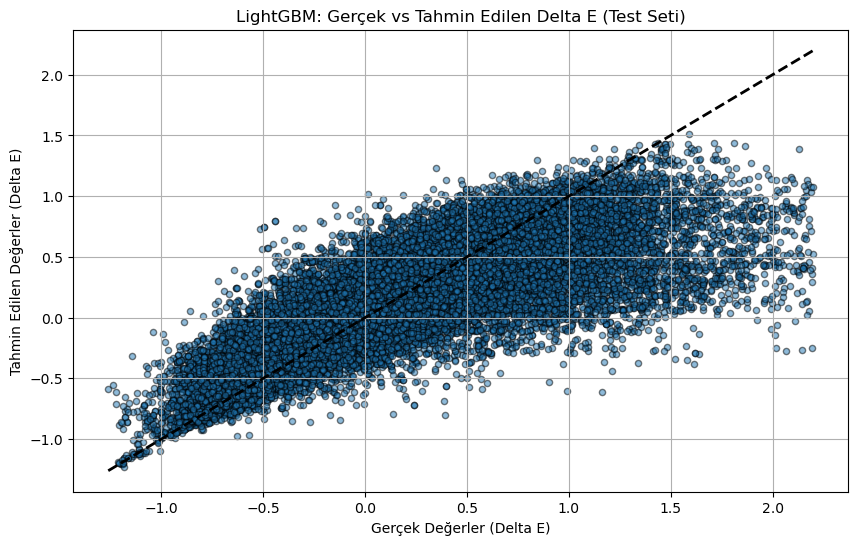

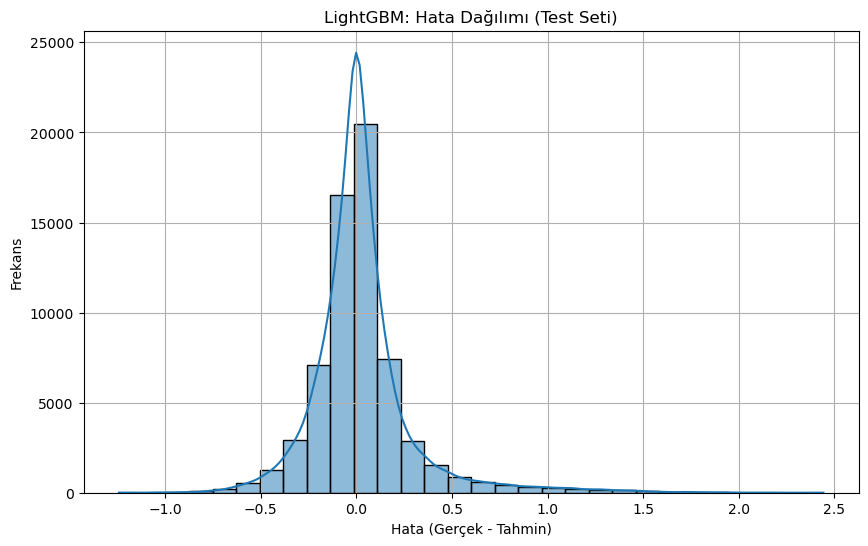

Model 'lightgbm_delta_e_model.txt' olarak kaydedildi.
Ölçekleyici 'lightgbm_scaler.joblib' olarak kaydedildi.
Model özellikleri 'lightgbm_model_features.joblib' olarak kaydedildi.


In [4]:
# Bu hücre, Yeni Hücre 1, 2, 3, 4'teki tanımlamaların çalıştığını varsayar.
data_file_path = 'veri.csv'
trained_model, trained_scaler, model_feature_cols = None, None, None

print("\n--- Blok 1: Model Eğitimi, Değerlendirmesi ve Kaydedilmesi (Özellik Seçimi ile) ---")
if not os.path.exists(data_file_path):
    print(f"HATA: Veri dosyası '{data_file_path}' bulunamadı.")
else:
    lgbm_custom_params = {
        'objective': 'regression_l1', 
        'metric': 'mae', 
        'n_estimators': 1500, 
        'learning_rate': 0.03,
        'num_leaves': 31, 
        'max_depth': -1, 
        'min_child_samples': 20, 
        'feature_fraction': 0.8, 
        'bagging_fraction': 0.8, 
        'bagging_freq': 1, 
        'lambda_l1': 0.1, 
        'lambda_l2': 0.1, 
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42,
        'boosting_type': 'gbdt',
    }
    
    trained_model, trained_scaler, model_feature_cols = train_evaluate_save_model(
        data_path=data_file_path,
        min_non_zero_frac_filter=0.01, 
        variance_threshold_filter=1e-5,
        target_column='delta_e',
        lgbm_params=lgbm_custom_params
    )

In [5]:
# Bu hücre trained_model, trained_scaler, model_feature_cols'ü Yeni Hücre 5'ten alır.
if trained_model and model_feature_cols:
    print("\n--- Blok 2: Rastgele Kompozisyonlarla En Düşük Delta E Arama ---")
    
    possible_elements = ['Fe', 'Ni', 'Al', 'Cr', 'Co', 'Si', 'C', 'Mo', 'W', 'V', 'Mn', 'Ti', 'Nb', 'Zr', 'Hf', 'Ta', 'Re', 'Ru', 'B', 'P', 'S']
    elements_for_search = [elem for elem in possible_elements if elem in model_feature_cols]

    if elements_for_search:
        print(f"Arama için kullanılacak elementler (modelde olanlar ve listeden seçilenler): {elements_for_search}")
        
        fixed_s_features = {}
        if 'comp_ntypes' in model_feature_cols:
            fixed_s_features['comp_ntypes'] = "dynamic_from_comp" 
        
        print(f"Blok 2 için sabit özellikler (varsa): {fixed_s_features}")

        min_delta_e_val, best_comp_details = find_min_delta_e_random(
            model=trained_model,
            elements_to_vary=elements_for_search,
            all_feature_cols=model_feature_cols,
            scaler=trained_scaler,
            n_iter=1000, # Orijinal notebook'taki değer
            min_frac=0.02, # Orijinal notebook'taki değer
            fixed_features=fixed_s_features
        )
    else:
        print("Model özelliklerinde veya tanımlı listede arama için uygun element bulunamadı.")
elif not os.path.exists(data_file_path) and trained_model is None:
    print(f"HATA: Veri dosyası '{data_file_path}' bulunamadığından ve model eğitilemediğinden Blok 2 çalıştırılamıyor.")
elif not trained_model:
    print("\nModel eğitilemediği için Blok 2 çalıştırılamıyor.")


--- Blok 2: Rastgele Kompozisyonlarla En Düşük Delta E Arama ---
Arama için kullanılacak elementler (modelde olanlar ve listeden seçilenler): ['Fe', 'Ni', 'Al', 'Cr', 'Co', 'Si', 'C', 'Mo', 'W', 'V', 'Mn', 'Ti', 'Nb', 'Zr', 'Hf', 'Ta', 'Re', 'Ru', 'B']
Blok 2 için sabit özellikler (varsa): {'comp_ntypes': 'dynamic_from_comp'}
1000 iterasyon boyunca rastgele kompozisyonlar deneniyor...
Iterasyon 100/1000... En düşük ΔE: -0.6959
Iterasyon 200/1000... En düşük ΔE: -0.6959
Iterasyon 300/1000... En düşük ΔE: -0.7392
Iterasyon 400/1000... En düşük ΔE: -0.7392
Iterasyon 500/1000... En düşük ΔE: -0.7392
Iterasyon 600/1000... En düşük ΔE: -0.7392
Iterasyon 700/1000... En düşük ΔE: -0.7392
Iterasyon 800/1000... En düşük ΔE: -0.7392
Iterasyon 900/1000... En düşük ΔE: -0.7392
Iterasyon 1000/1000... En düşük ΔE: -0.7392

En Düşük ΔE (Rastgele Arama): -0.7392
Bulunan Kompozisyon (ve ilgili özellikler): {'comp_ntypes': 6, 'Ni': 0.0561935680544824, 'Hf': 0.09484860497292306, 'Al': 0.01956406543700946

In [6]:
# Bu hücre trained_model, trained_scaler, model_feature_cols'ü Yeni Hücre 5'ten alır.
if trained_model and model_feature_cols:
    print("\n--- Blok 3: Spesifik Kompozisyonlar İçin Delta E Tahmini ---")
    
    # Örnek 1
    specific_composition_1_elements = {'Fe': 0.6, 'Cr': 0.2, 'Ni': 0.1, 'Mo': 0.1}
    # Sadece modelin bildiği elementleri al ve comp_ntypes'ı buna göre ayarla
    comp_to_predict_1 = {k:v for k,v in specific_composition_1_elements.items() if k in model_feature_cols}
    if 'comp_ntypes' in model_feature_cols:
        # comp_ntypes'ı sadece element olan anahtarların sayısına göre ayarla
        element_keys_in_comp1 = [k for k in comp_to_predict_1.keys() if k != 'comp_ntypes']
        comp_to_predict_1['comp_ntypes'] = len(element_keys_in_comp1) 

    # Tahmin için en az bir geçerli element olduğundan ve orijinal elementlerin en az yarısının modelde olduğundan emin ol
    original_element_keys_1 = [k for k in specific_composition_1_elements.keys() if k != 'comp_ntypes']
    valid_element_keys_1 = [k for k in comp_to_predict_1.keys() if k != 'comp_ntypes' and comp_to_predict_1[k] > 0]

    if valid_element_keys_1 and len(valid_element_keys_1) >= len(original_element_keys_1) * 0.5:
        predict_delta_e_specific(
            composition_dict=comp_to_predict_1,
            model=trained_model,
            all_feature_cols=model_feature_cols,
            scaler=trained_scaler
        )
    else:
        print(f"'{specific_composition_1_elements}' için yeterli sayıda eşleşen özellik ({len(valid_element_keys_1)}/{len(original_element_keys_1)}) bulunamadı veya hiç geçerli element yok, tahmin atlanıyor.")

    # Örnek 2: Farklı bir kompozisyon
    another_composition_elements = {'Al': 0.5, 'Ti': 0.3, 'V': 0.2}
    comp_to_predict_2 = {k:v for k,v in another_composition_elements.items() if k in model_feature_cols}
    if 'comp_ntypes' in model_feature_cols:
        element_keys_in_comp2 = [k for k in comp_to_predict_2.keys() if k != 'comp_ntypes']
        comp_to_predict_2['comp_ntypes'] = len(element_keys_in_comp2)
    
    original_element_keys_2 = [k for k in another_composition_elements.keys() if k != 'comp_ntypes']
    valid_element_keys_2 = [k for k in comp_to_predict_2.keys() if k != 'comp_ntypes' and comp_to_predict_2[k] > 0]

    if valid_element_keys_2 and len(valid_element_keys_2) >= len(original_element_keys_2) * 0.5:
         predict_delta_e_specific(
            composition_dict=comp_to_predict_2,
            model=trained_model,
            all_feature_cols=model_feature_cols,
            scaler=trained_scaler
        )
    else:
        print(f"'{another_composition_elements}' için yeterli sayıda eşleşen özellik ({len(valid_element_keys_2)}/{len(original_element_keys_2)}) bulunamadı veya hiç geçerli element yok, tahmin atlanıyor.")

elif not os.path.exists(data_file_path) and trained_model is None:
     print(f"HATA: Veri dosyası '{data_file_path}' bulunamadığından ve model eğitilemediğinden Blok 3 çalıştırılamıyor.")
elif not trained_model:
    print("\nModel eğitilemediği için Blok 3 çalıştırılamıyor.")


--- Blok 3: Spesifik Kompozisyonlar İçin Delta E Tahmini ---

Spesifik kompozisyon için tahmin: {'Fe': 0.6, 'Cr': 0.2, 'Ni': 0.1, 'Mo': 0.1, 'comp_ntypes': 4}
Tahmin Edilen ΔE: -0.0826

Spesifik kompozisyon için tahmin: {'Al': 0.5, 'Ti': 0.3, 'V': 0.2, 'comp_ntypes': 3}
Tahmin Edilen ΔE: -0.0327
